# Monte Carlo Option Pricing and Black-Scholes Comparison

This project aims to estimate the price of a European call option using Monte Carlo simulation and compare the results with the Black-Scholes analytical model.

## 1. Introduction

In financial markets, option pricing is a fundamental problem. This project uses Monte Carlo simulation to estimate the price of a European call option by generating multiple possible future stock price paths.

The results are then compared with the Black-Scholes analytical formula to validate the accuracy of the simulation.

We also analyze how the number of simulations affects the stability and accuracy of the estimated option price.

## 2. Imports and Parameters

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
S0 = 100
K = 105
T = 1
r = 0.05
sigma = 0.2
n_steps = 252

dt = T / n_steps

## 3. Monte Carlo Simulation with 1000 Simulations

In this section, 1000 possible stock price paths are simulated. The first 100 paths are plotted to visualize possible future price movements.

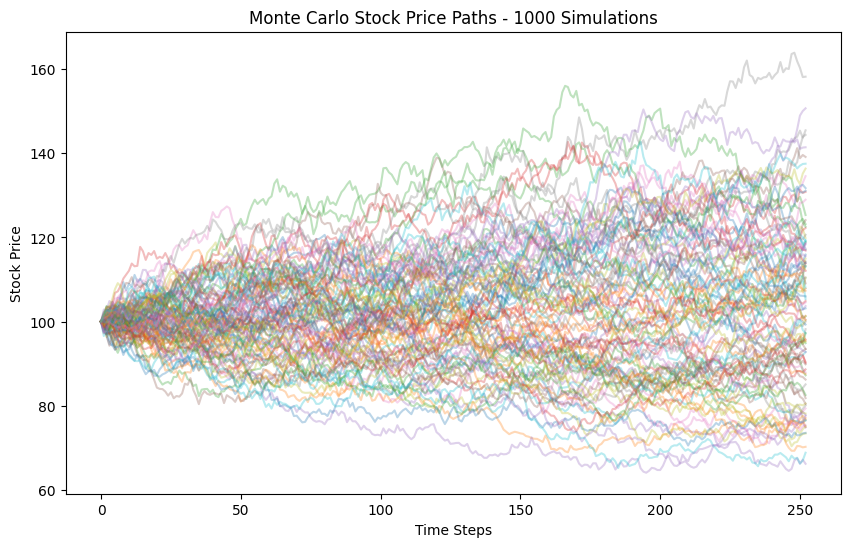

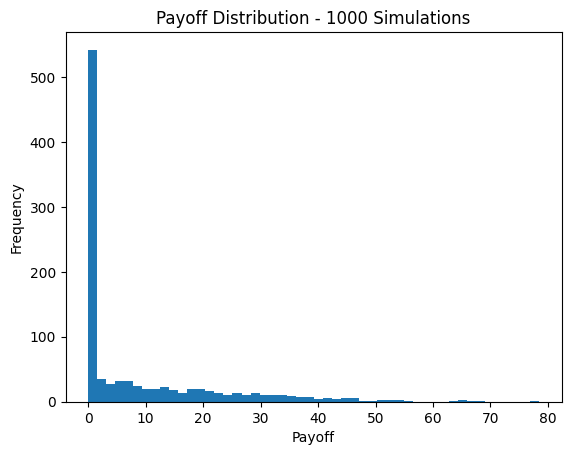

Monte Carlo Option Price with 1000 simulations: 8.25863037727564


In [5]:
n_simulations = 1000
payoffs_1000 = []

plt.figure(figsize=(10, 6))

for sim in range(n_simulations):
    S = S0
    path = [S0]

    for i in range(n_steps):
        z = np.random.normal()
        S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
        path.append(S)

    payoff = max(S - K, 0)
    payoffs_1000.append(payoff)

    if sim < 100:
        plt.plot(path, alpha=0.3)

plt.title("Monte Carlo Stock Price Paths - 1000 Simulations")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.show()

plt.hist(payoffs_1000, bins=50)
plt.title("Payoff Distribution - 1000 Simulations")
plt.xlabel("Payoff")
plt.ylabel("Frequency")
plt.show()

mc_1000 = np.exp(-r * T) * np.mean(payoffs_1000)

print("Monte Carlo Option Price with 1000 simulations:", mc_1000)

With 1000 simulations, the estimated option price may still show some variability because the result depends on random simulations.

## 4. Monte Carlo Simulation with 5000 Simulations

In this section, the number of simulations is increased to 5000. Increasing the number of simulations generally improves the stability of the estimated option price.

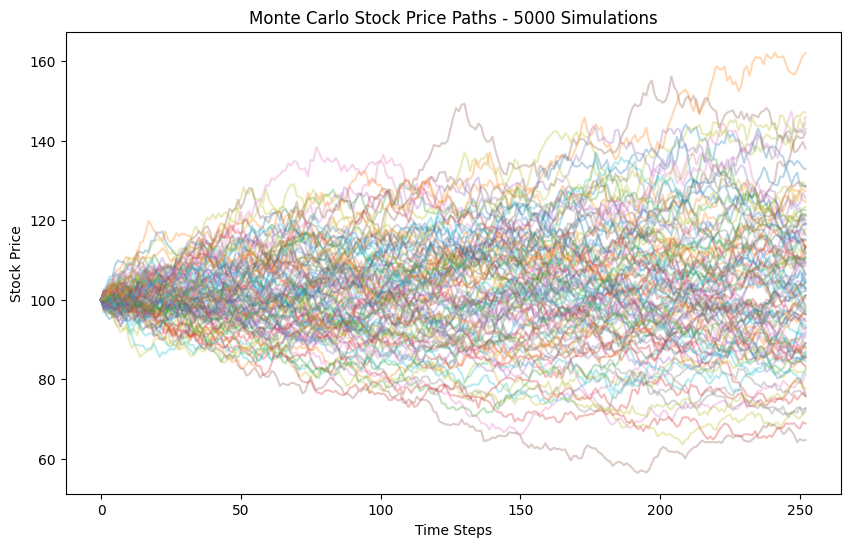

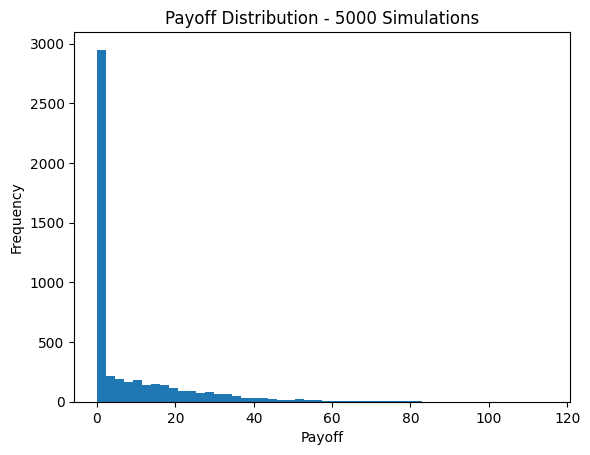

Monte Carlo Option Price with 5000 simulations: 7.739325840044875


In [6]:
n_simulations = 5000
payoffs_5000 = []

plt.figure(figsize=(10, 6))

for sim in range(n_simulations):
    S = S0
    path = [S0]

    for i in range(n_steps):
        z = np.random.normal()
        S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
        path.append(S)

    payoff = max(S - K, 0)
    payoffs_5000.append(payoff)

    if sim < 100:
        plt.plot(path, alpha=0.3)

plt.title("Monte Carlo Stock Price Paths - 5000 Simulations")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.show()

plt.hist(payoffs_5000, bins=50)
plt.title("Payoff Distribution - 5000 Simulations")
plt.xlabel("Payoff")
plt.ylabel("Frequency")
plt.show()

mc_5000 = np.exp(-r * T) * np.mean(payoffs_5000)

print("Monte Carlo Option Price with 5000 simulations:", mc_5000)

With 5000 simulations, the option price estimate becomes more stable compared to 1000 simulations.

## 5. Monte Carlo Simulation with 10000 Simulations

In this section, 10000 simulations are performed. A higher number of simulations usually provides a more reliable estimate, although it requires more computational time.

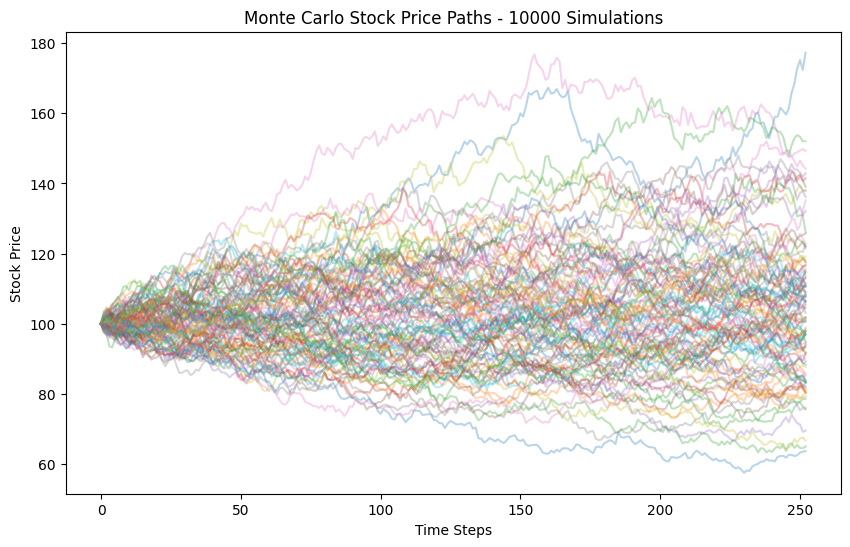

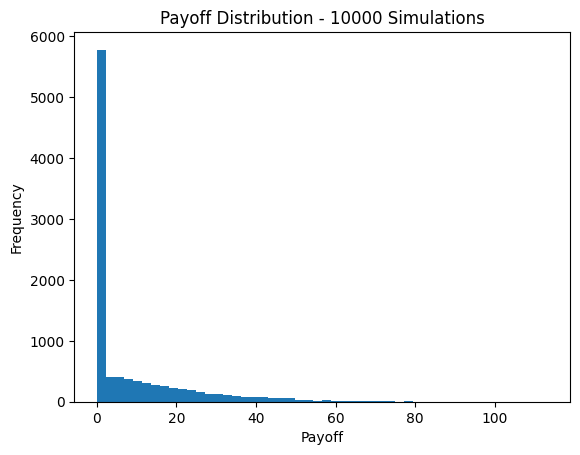

Monte Carlo Option Price with 10000 simulations: 8.04394281179201


In [7]:
n_simulations = 10000
payoffs_10000 = []

plt.figure(figsize=(10, 6))

for sim in range(n_simulations):
    S = S0
    path = [S0]

    for i in range(n_steps):
        z = np.random.normal()
        S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
        path.append(S)

    payoff = max(S - K, 0)
    payoffs_10000.append(payoff)

    if sim < 100:
        plt.plot(path, alpha=0.3)

plt.title("Monte Carlo Stock Price Paths - 10000 Simulations")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")
plt.show()

plt.hist(payoffs_10000, bins=50)
plt.title("Payoff Distribution - 10000 Simulations")
plt.xlabel("Payoff")
plt.ylabel("Frequency")
plt.show()

mc_10000 = np.exp(-r * T) * np.mean(payoffs_10000)

print("Monte Carlo Option Price with 10000 simulations:", mc_10000)

With 10000 simulations, the Monte Carlo estimate becomes more stable and should be closer to the theoretical Black-Scholes price.

## 6. Black-Scholes Analytical Model

The Black-Scholes model provides an analytical formula for pricing European call options. It is used here as a benchmark to compare the Monte Carlo results.

In [8]:
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

bs_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print("Black-Scholes Option Price:", bs_price)

Black-Scholes Option Price: 8.021352235143176


## 7. Comparison of Monte Carlo and Black-Scholes Results

In [9]:
simulations = [1000, 5000, 10000]
mc_prices = [mc_1000, mc_5000, mc_10000]
bs_prices = [bs_price, bs_price, bs_price]

for sim, mc, bs in zip(simulations, mc_prices, bs_prices):
    difference = abs(mc - bs)
    print(f"Simulations: {sim}")
    print(f"Monte Carlo Price: {mc}")
    print(f"Black-Scholes Price: {bs}")
    print(f"Difference: {difference}")
    print("--------------------------")

Simulations: 1000
Monte Carlo Price: 8.25863037727564
Black-Scholes Price: 8.021352235143176
Difference: 0.2372781421324639
--------------------------
Simulations: 5000
Monte Carlo Price: 7.739325840044875
Black-Scholes Price: 8.021352235143176
Difference: 0.28202639509830174
--------------------------
Simulations: 10000
Monte Carlo Price: 8.04394281179201
Black-Scholes Price: 8.021352235143176
Difference: 0.02259057664883457
--------------------------


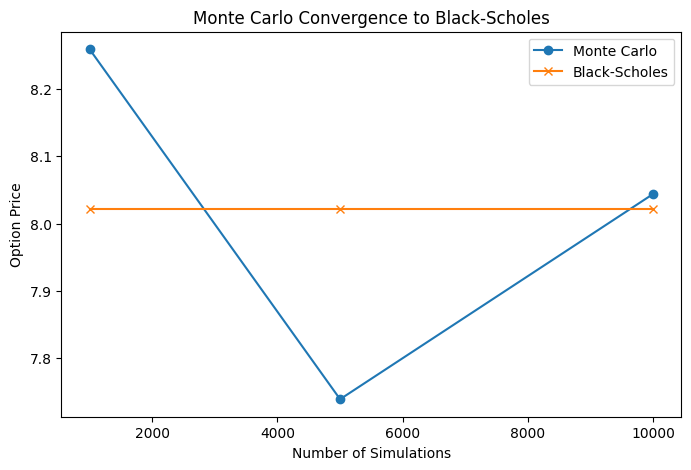

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(simulations, mc_prices, marker='o', label='Monte Carlo')
plt.plot(simulations, bs_prices, marker='x', label='Black-Scholes')

plt.title("Monte Carlo Convergence to Black-Scholes")
plt.xlabel("Number of Simulations")
plt.ylabel("Option Price")
plt.legend()
plt.show()

The results show that the Monte Carlo option price becomes more stable as the number of simulations increases.

The difference between the Monte Carlo estimate and the Black-Scholes price is caused by randomness in the simulation. As the number of simulations increases, this difference generally decreases.

This demonstrates the convergence property of Monte Carlo simulation.

## 8. Volatility (Sigma) Sensitivity Analysis

In this section, we analyze how changes in volatility affect the option price. Volatility is a key parameter in option pricing models and has a significant impact on the option value.

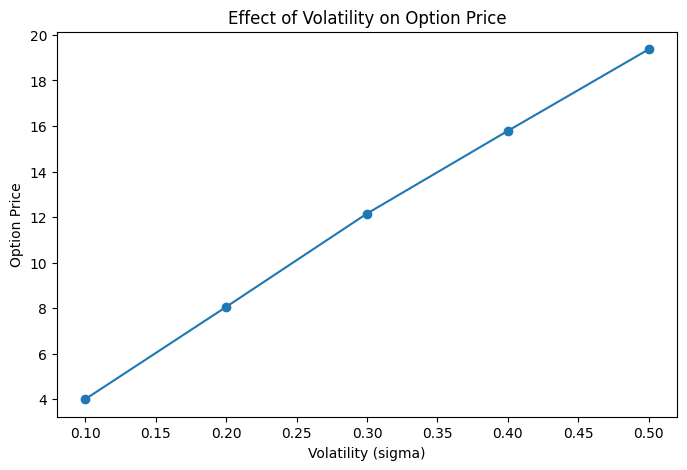

In [11]:
sigma_values = [0.1, 0.2, 0.3, 0.4, 0.5]
option_prices = []

n_simulations = 5000  # orta seviye

for sigma_test in sigma_values:
    payoffs = []

    for sim in range(n_simulations):
        S = S0

        for i in range(n_steps):
            z = np.random.normal()
            S = S * np.exp((r - 0.5 * sigma_test**2) * dt + sigma_test * np.sqrt(dt) * z)

        payoff = max(S - K, 0)
        payoffs.append(payoff)

    price = np.exp(-r * T) * np.mean(payoffs)
    option_prices.append(price)

# grafik
plt.figure(figsize=(8,5))
plt.plot(sigma_values, option_prices, marker='o')

plt.title("Effect of Volatility on Option Price")
plt.xlabel("Volatility (sigma)")
plt.ylabel("Option Price")
plt.show()

## 9. Conclusion

This project implemented Monte Carlo simulation to estimate the price of a European call option. The stock price was modeled using Geometric Brownian Motion, and the option payoff was calculated at maturity.

The results were compared with the Black-Scholes analytical solution. The comparison showed that Monte Carlo simulation can approximate the theoretical option price, especially when the number of simulations is increased.

Additionally, a sensitivity analysis on volatility was conducted. The results showed that as volatility increases, the option price also increases. This is because higher volatility leads to greater uncertainty in future stock prices, increasing the likelihood of higher payoffs.

This project demonstrates the use of simulation, probability, and financial modeling in quantitative finance.